# BCE Training Pipeline — Demo

Demonstrates `run_training` with `type='bce'`. W&B logging is skipped.

**Assumes** `cfg` is already defined with the expected structure:
- `cfg.data.path`
- `cfg.model.hidden_layers`, `cfg.model.activations`
- `cfg.training.epochs`, `cfg.training.batch_size`, `cfg.training.lr`, `cfg.training.pos_weight`

## 1. Imports

In [1]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from src.data import load_data, PlayerDataset
from src.model import MLP
from src.trainer import Trainer
from src.config import load_config

## 2. Load Config

In [2]:
cfg = load_config("configs/base.yaml")

## 3. Load & Split Data

In [16]:
X, y, feature_names = load_data(cfg.data.path)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Class balance (train): {np.bincount(y_train.astype(int))}")

Class balance (train): [461212   5718]


## 4. DataLoaders

In [4]:
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_workers = 4 if torch.cuda.is_available() else 0
pin_memory  = (device.type == "cuda")

print(f"Using device: {device}")

train_loader = DataLoader(
    PlayerDataset(X_train, y_train),
    batch_size=cfg.training.batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

val_loader = DataLoader(
    PlayerDataset(X_test, y_test),
    batch_size=cfg.training.batch_size,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

Using device: cpu


## 5. Model, Criterion, Optimizer, Scheduler

In [5]:
model = MLP(
    input_dim=X_train.shape[1],
    hidden_layers=cfg.model.hidden_layers,
    activations=cfg.model.activations,
).to(device)

criterion = torch.nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([cfg.training.pos_weight], device=device)
)

optimizer = torch.optim.Adam(model.parameters(), lr=cfg.training.lr)

scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=22, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): Tanh()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)


## 6. Training

In [6]:
trainer = Trainer(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    device=device,
)

history = trainer.fit(
    train_loader,
    val_loader,
    epochs=3,
    verbose=True,
)

Epoch 1 | loss=0.2633 | val loss=0.2365 | val_acc=0.9770 | val_f1=0.1695
Epoch 2 | loss=0.2317 | val loss=0.2334 | val_acc=0.9662 | val_f1=0.1747
Epoch 3 | loss=0.2296 | val loss=0.2325 | val_acc=0.9653 | val_f1=0.1753
Epoch 4 | loss=0.2285 | val loss=0.2321 | val_acc=0.9638 | val_f1=0.1745
Epoch 5 | loss=0.2279 | val loss=0.2321 | val_acc=0.9696 | val_f1=0.1776
Epoch 6 | loss=0.2275 | val loss=0.2317 | val_acc=0.9716 | val_f1=0.1778
Epoch 7 | loss=0.2269 | val loss=0.2316 | val_acc=0.9677 | val_f1=0.1781
Epoch 8 | loss=0.2267 | val loss=0.2314 | val_acc=0.9702 | val_f1=0.1786
Epoch 9 | loss=0.2264 | val loss=0.2314 | val_acc=0.9720 | val_f1=0.1784
Epoch 10 | loss=0.2261 | val loss=0.2315 | val_acc=0.9712 | val_f1=0.1780


## 7. Visualisation

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

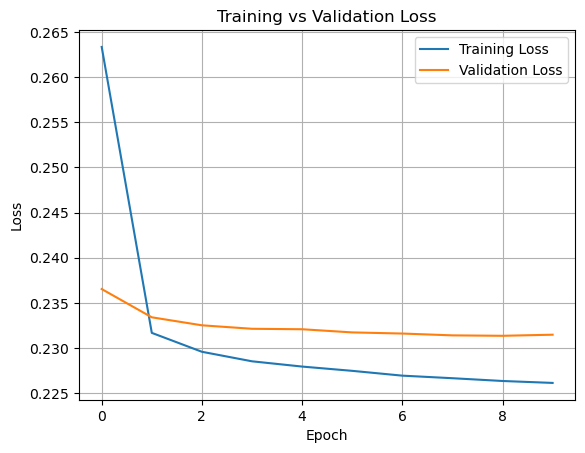

In [9]:
plt.figure()
plt.plot(history["loss"],     label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

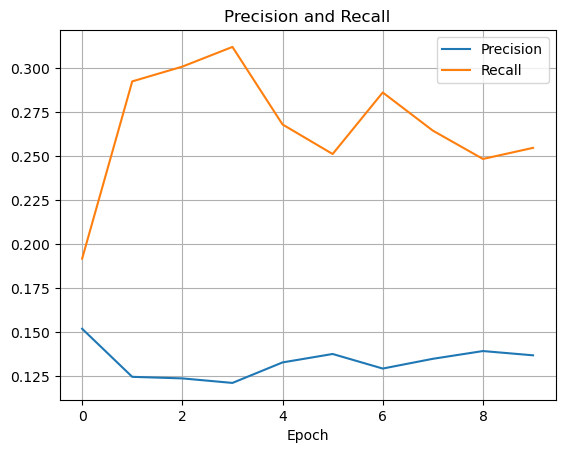

In [11]:
plt.figure()
plt.plot(history["val_precision"], label="Precision")
plt.plot(history["val_recall"],    label="Recall")
plt.xlabel("Epoch")
plt.title("Precision and Recall")
plt.legend()
plt.grid()
plt.show()

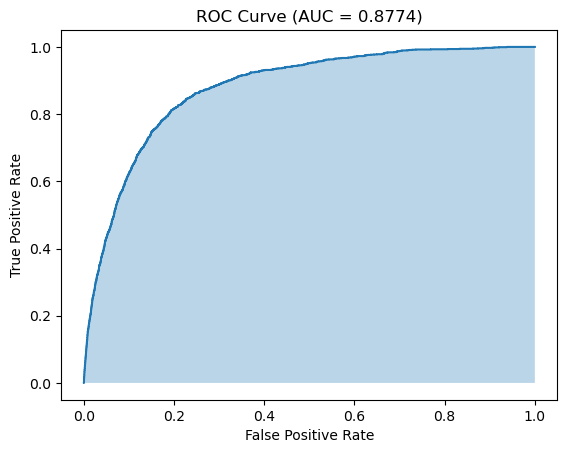

In [13]:
fpr, tpr, thresholds, roc_auc = trainer.roc_values(val_loader)

plt.figure()
plt.plot(fpr, tpr)
plt.fill_between(fpr, tpr, alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")
plt.show()

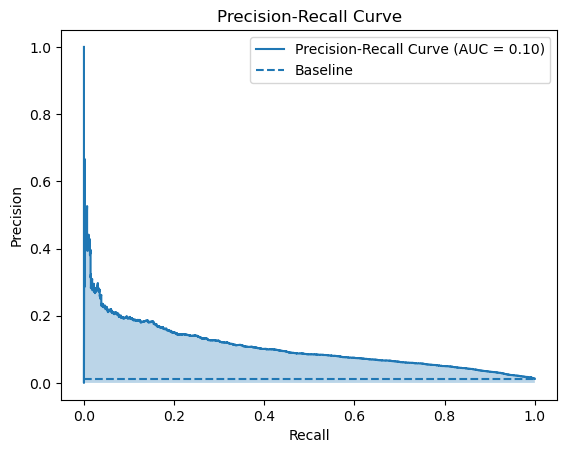

In [12]:
precision, recall, thresholds, pr_auc = trainer.pr_values(val_loader)

plt.figure()
plt.plot(recall, precision, label=f"Precision-Recall Curve (AUC = {pr_auc:.2f})")
plt.hlines(np.mean(y_test), 0, 1, linestyles="dashed", label="Baseline")
plt.fill_between(recall, precision, alpha=0.3)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

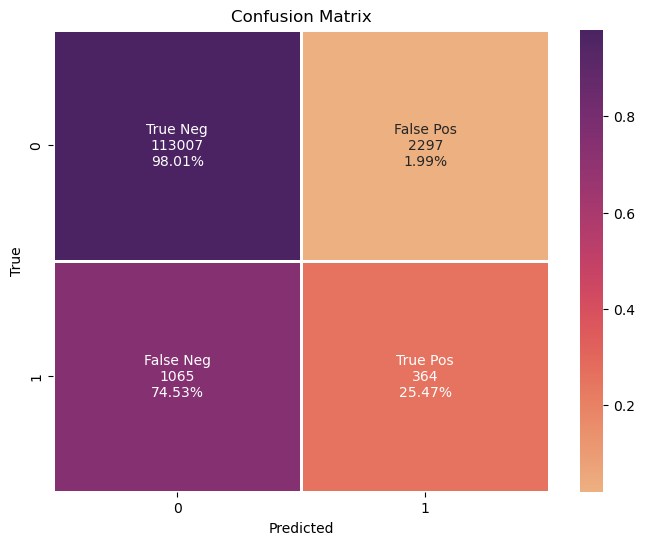

In [10]:
threshold = history["best_t"][-1]
cm = trainer.confusion_matrix(val_loader, threshold=threshold)

df   = pd.DataFrame(cm)
perc = df.div(df.sum(axis=1), axis=0)
names = np.array([["True Neg", "False Pos"], ["False Neg", "True Pos"]])
annot = (
    names + "\n" +
    df.astype(str) + "\n" +
    perc.multiply(100).round(2).astype(str) + "%"
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    perc,
    annot=annot,
    fmt="",
    cmap="flare",
    linewidths=1,
    cbar=True,
    annot_kws={"fontsize": 10},
    ax=ax,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [14]:
import shap
import numpy as np

import matplotlib.pyplot as plt
from src.explainability.helper import get_samples

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_tensor  = torch.tensor(X_test,  dtype=torch.float32).to(device)

def model_forward(x):
    return torch.sigmoid(model(x)).squeeze(1)

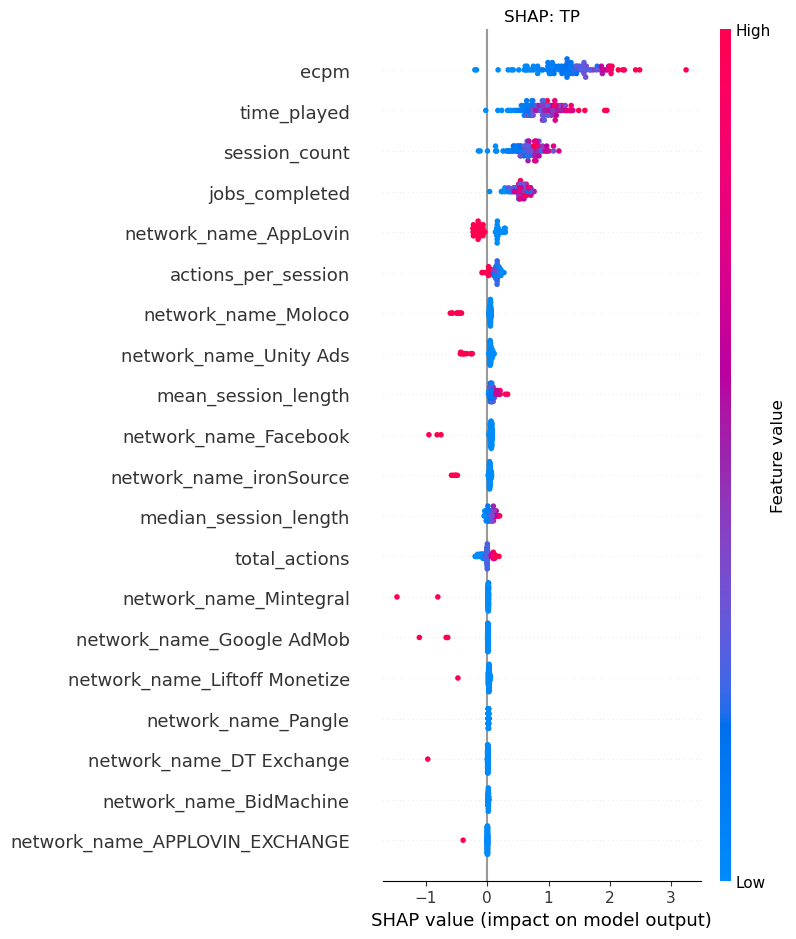

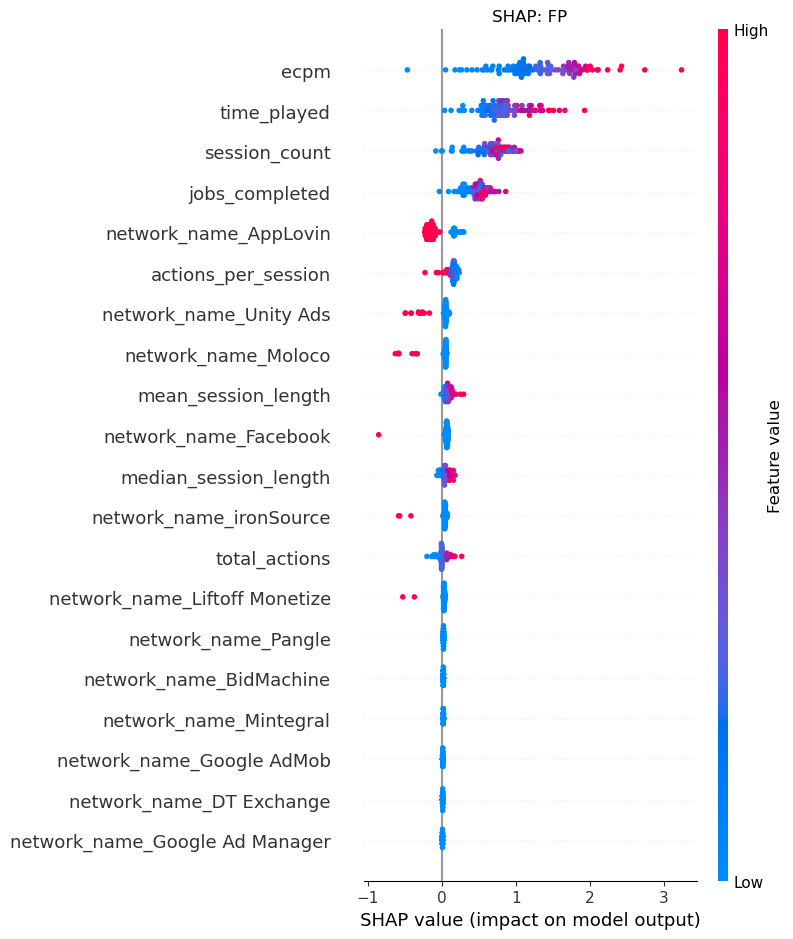

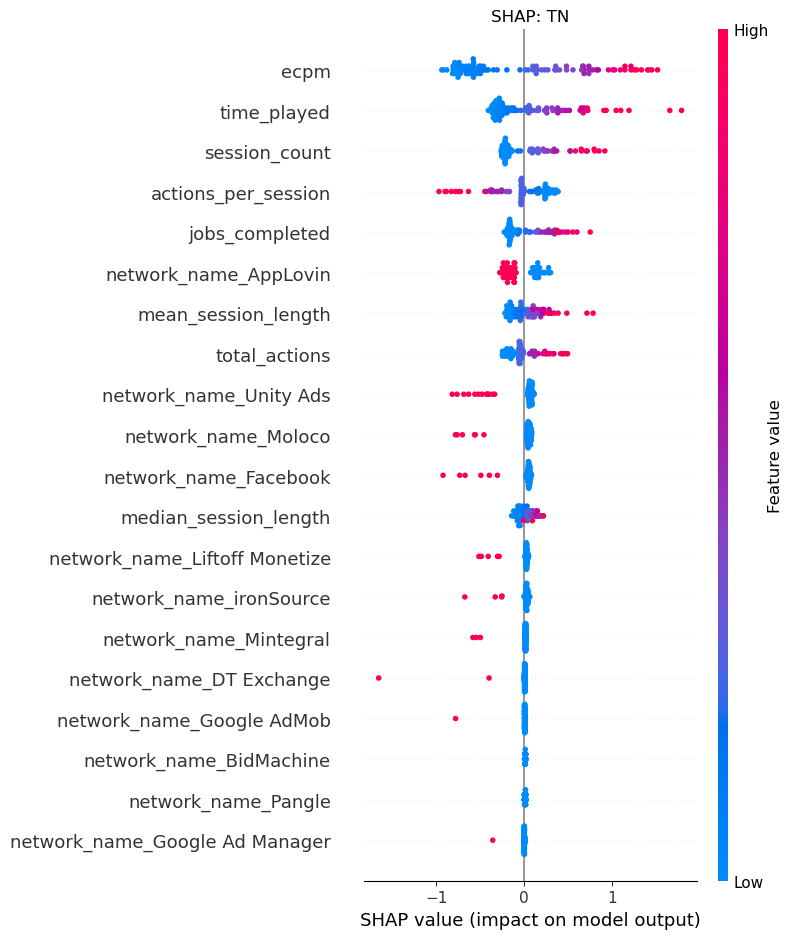

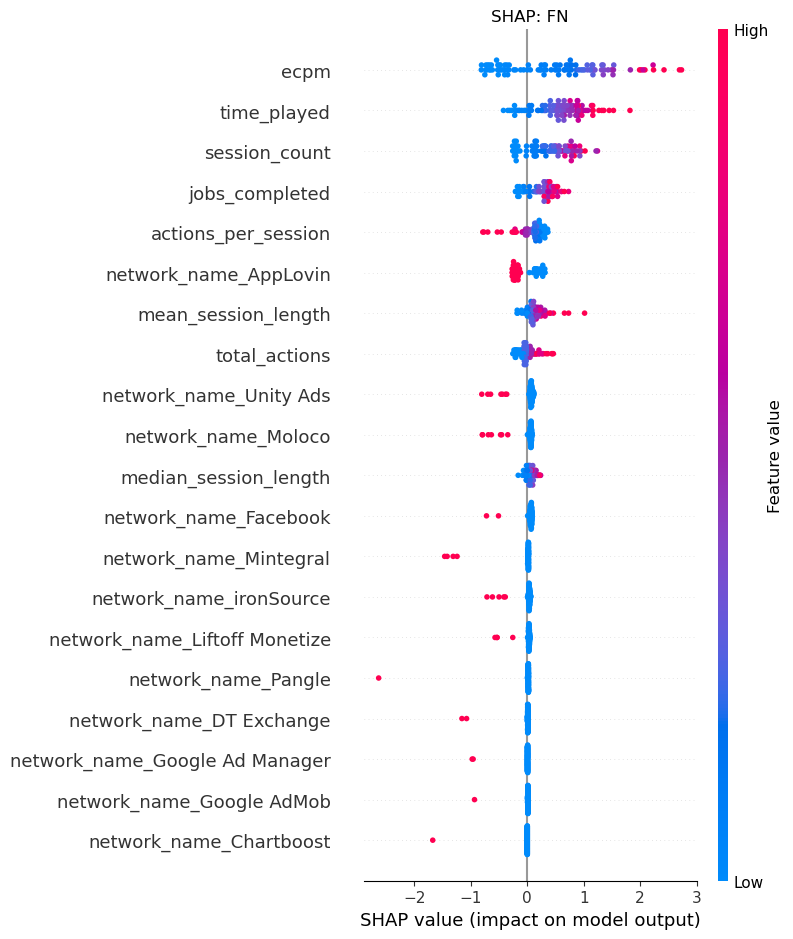

In [18]:
model.eval()
groups = get_samples(cfg, model)

bg = shap.sample(X_train_tensor, 500)
explainer = shap.DeepExplainer(model, bg)

for group, mask in groups.items():
    indices = np.where(mask)[0]
    X_sub = X_test_tensor[indices[:100]]

    shap_vals = np.squeeze(explainer.shap_values(X_sub))

    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP: {group}")
    shap.summary_plot(shap_vals, X_sub.cpu().numpy(), feature_names=feature_names, show=True)